In [31]:
# =========================================================
# AI-Driven Smart Logistics & Supply Chain Intelligence System
# Final Exam Project
# Student: Malika Zharova
# =========================================================

In [32]:
# IMPORT LIBRARIES

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier


In [34]:
# LOAD DATASET

In [35]:
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

print(df.head())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  ...  \
0   PMO - US  Direct Drop              EXW           Air  ...   
1   PMO - US  Direct Drop              EXW           Air  ...   
2   PMO - US  Direct Drop              FCA           Air  ...   
3   PMO - US  Direct Drop              EXW           Air  ...   
4   PMO - US  Direct Drop              EXW           Air  ...   

  Unit of Measure (Per Pack) Line Item Quantity Line Item Value Pack Price  \
0                         30                 19           551.0      29.00   
1                   

In [36]:
# BASIC INFORMATION

In [37]:
print(df.info())

print(df.describe())

print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [38]:
# TASK 1 — DATA CLEANING & PREPARATION

In [39]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values for specific categorical columns with a string 'Unknown' first
# This ensures that LabelEncoder receives uniform string types.
for col in ['Shipment Mode', 'Country']:
    if col in df.columns:
        df[col] = df[col].replace(0, 'Unknown').fillna('Unknown').astype(str)

# Fill remaining missing values with 0
df = df.fillna(0)

# Convert dates
df['Scheduled Delivery Date'] = pd.to_datetime(
    df['Scheduled Delivery Date']
)

df['Delivered to Client Date'] = pd.to_datetime(
    df['Delivered to Client Date']
)

# Convert 'Freight Cost (USD)' to numeric, handling potential non-numeric characters more robustly
df['Freight Cost (USD)'] = df['Freight Cost (USD)'].astype(str) # Ensure it's string type
df['Freight Cost (USD)'] = df['Freight Cost (USD)'].str.replace('[^\\d.]', '', regex=True) # Remove non-numeric characters except digits and dot
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce') # Convert to numeric
df['Freight Cost (USD)'] = df['Freight Cost (USD)'].fillna(0) # Fill any NaNs resulting from coercion

# Create delivery days column
df['Delivery Days'] = (
    df['Delivered to Client Date']
    - df['Scheduled Delivery Date']
).dt.days

# Create delay status column
df['Delay Status'] = np.where(
    df['Delivery Days'] > 0,
    'Delayed',
    'On Time'
)

# Create total cost column
df['Total Cost'] = (
    df['Line Item Quantity']
    * df['Line Item Value']
)

print(df.head())

/tmp/ipykernel_12842/1102597152.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Scheduled Delivery Date'] = pd.to_datetime(
/tmp/ipykernel_12842/1102597152.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivered to Client Date'] = pd.to_datetime(


   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  ... Pack Price  \
0   PMO - US  Direct Drop              EXW           Air  ...      29.00   
1   PMO - US  Direct Drop              EXW           Air  ...       6.20   
2   PMO - US  Direct Drop              FCA           Air  ...      80.00   
3   PMO - US  Direct Drop              EXW           Air  ...       3.99   
4   PMO - US  Direct Drop              EXW           Air  ...       3.20   

  Unit Price             Manufacturing Site First Line Designation  \
0       0.97     Ranbaxy Fine Chemicals 

In [40]:
# TASK 2 — EXPLORATORY DATA ANALYSIS (EDA)

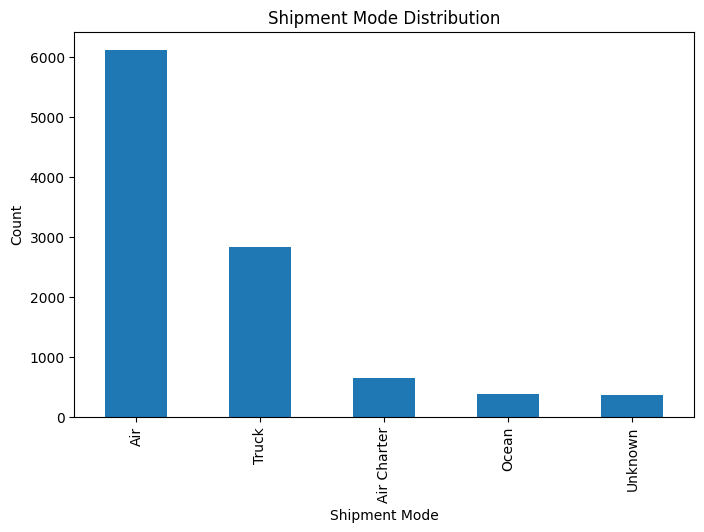

In [41]:
# Shipment Mode Count

shipment_counts = df['Shipment Mode'].value_counts()

plt.figure(figsize=(8,5))
shipment_counts.plot(kind='bar')

plt.title('Shipment Mode Distribution')
plt.xlabel('Shipment Mode')
plt.ylabel('Count')

plt.show()

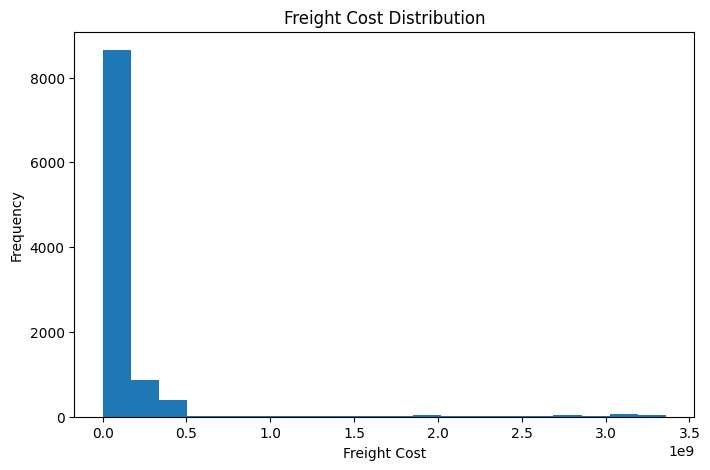

In [42]:
# Freight Cost Distribution
# This plot expects numerical data for 'Freight Cost (USD)'.
# Ensure this column is correctly converted to numeric upstream if issues arise.

plt.figure(figsize=(8,5))

plt.hist(df['Freight Cost (USD)'], bins=20)

plt.title('Freight Cost Distribution')
plt.xlabel('Freight Cost')
plt.ylabel('Frequency')

plt.show()

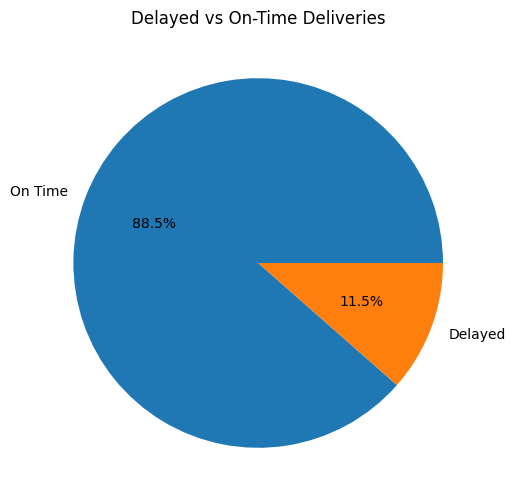

In [43]:
# Delivery Delay Count

delay_counts = df['Delay Status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delay_counts,
    labels=delay_counts.index,
    autopct='%1.1f%%'
)

plt.title('Delayed vs On-Time Deliveries')

plt.show()


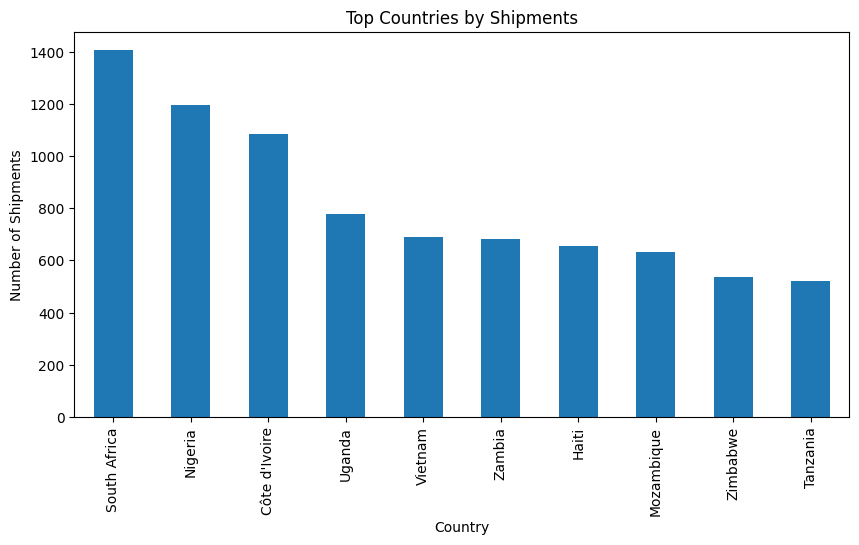

In [44]:
# Top Countries by Shipments

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title('Top Countries by Shipments')
plt.xlabel('Country')
plt.ylabel('Number of Shipments')

plt.show()

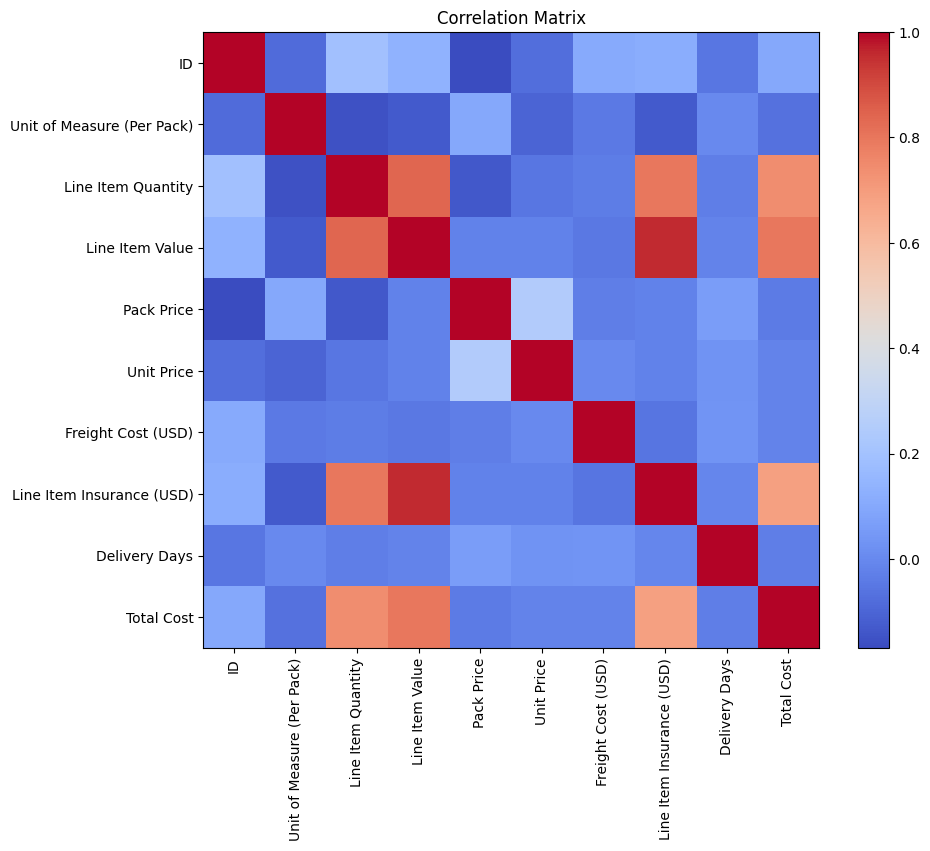

In [45]:
# Correlation Matrix

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Matrix')

plt.show()

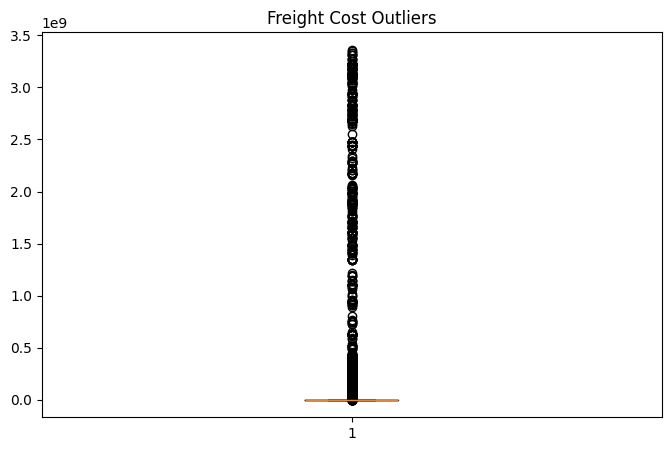

In [46]:
# Outlier Detection
df['Freight Cost (USD)'] = pd.to_numeric(
    df['Freight Cost (USD)'],
    errors='coerce'
)

freight_cost = df['Freight Cost (USD)'].dropna()

plt.figure(figsize=(8,5))

plt.boxplot(freight_cost)

plt.title('Freight Cost Outliers')

plt.show()


In [47]:
# =========================================================
# TASK 3 — DEMAND FORECASTING MODULE
# =========================================================

# Formula:
# y = β0 + β1x + ε


In [48]:
# Use quantity to predict total cost

X = df[['Line Item Quantity']]
y = df['Total Cost']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [49]:
# Linear Regression Model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)


Mean Squared Error: 2.405529919009852e+21


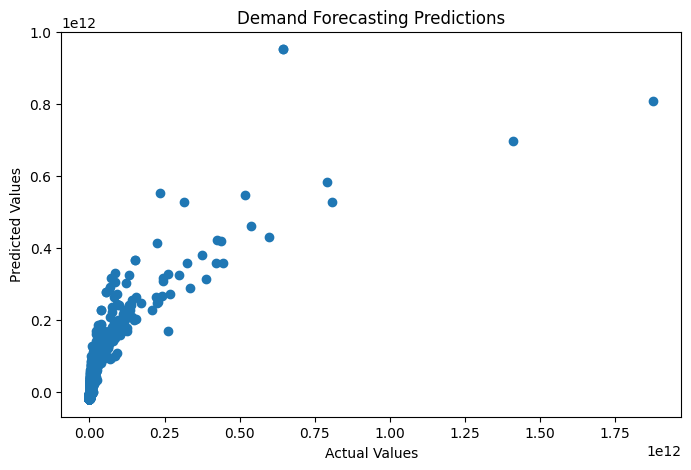

In [50]:
# Plot Predictions
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.title('Demand Forecasting Predictions')

plt.show()


In [51]:
# =========================================================
# TASK 4 — DELIVERY DELAY PREDICTION MODULE
# =========================================================

# Logistic Formula:
# P(Y=1) = 1 / (1 + e^-(β0 + β1x))

In [52]:
# Create binary target
df['Delayed'] = np.where(
    df['Delivery Days'] > 0,
    1,
    0
)

In [54]:
# Encode categorical columns
encoder = LabelEncoder()

df['Shipment Mode Encoded'] = encoder.fit_transform(
    df['Shipment Mode']
)

df['Country Encoded'] = encoder.fit_transform(
    df['Country']
)


In [58]:
# Features
X = df[[
    'Shipment Mode Encoded',
    'Country Encoded',
    'Line Item Quantity',
    'Freight Cost (USD)'
]]

# Target
y = df['Delayed']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [59]:
# Logistic Regression
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Accuracy: 0.886682808716707
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1834
           1       0.00      0.00      0.00       231

    accuracy                           0.89      2065
   macro avg       0.44      0.50      0.47      2065
weighted avg       0.79      0.89      0.83      2065

[[1831    3]
 [ 231    0]]


In [60]:
# =========================================================
# RANDOM FOREST CLASSIFIER
# =========================================================

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9002421307506053


In [61]:
# =========================================================
# TASK 5 — INVENTORY OPTIMIZATION MODULE
# =========================================================

# K-Means Formula:
# J = Σ Σ ||x − μi||²


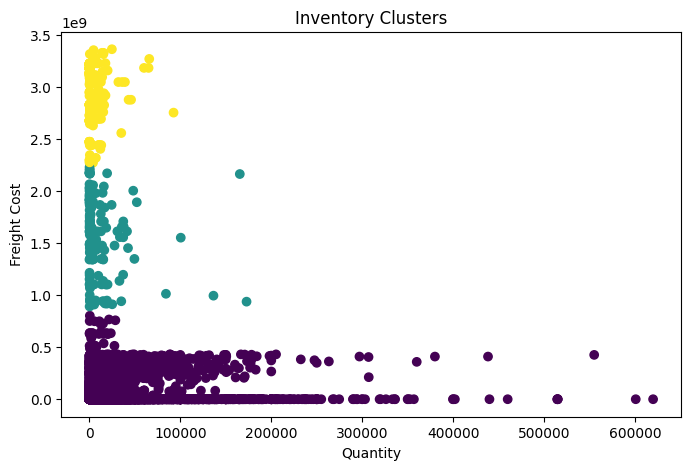

In [62]:
# Features for clustering
cluster_data = df[[
    'Line Item Quantity',
    'Freight Cost (USD)'
]]

# KMeans Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(cluster_data)

# Plot clusters
plt.figure(figsize=(8,5))

plt.scatter(
    df['Line Item Quantity'],
    df['Freight Cost (USD)'],
    c=df['Cluster']
)

plt.xlabel('Quantity')
plt.ylabel('Freight Cost')

plt.title('Inventory Clusters')

plt.show()



In [63]:
# =========================================================
# ABC ANALYSIS
# =========================================================

abc_df = df.groupby('Product Group')['Total Cost'].sum()

abc_df = abc_df.sort_values(ascending=False)

abc_df = abc_df.reset_index()

abc_df['Cumulative Percentage'] = (
    abc_df['Total Cost'].cumsum()
    / abc_df['Total Cost'].sum()
) * 100

# ABC Categories
conditions = [
    abc_df['Cumulative Percentage'] <= 80,
    abc_df['Cumulative Percentage'] <= 95
]

choices = ['A', 'B']

abc_df['Category'] = np.select(
    conditions,
    choices,
    default='C'
)

print(abc_df.head())


  Product Group    Total Cost  Cumulative Percentage Category
0           ARV  1.482710e+14              99.126308        C
1          HRDT  1.302136e+12              99.996849        C
2           ACT  3.289373e+09              99.999048        C
3          ANTM  1.308016e+09              99.999922        C
4          MRDT  1.164504e+08             100.000000        C


In [ ]:
# =========================================================
# TASK 6 — SUPPLIER & TRANSPORTATION ANALYTICS
# =========================================================


In [64]:
# Supplier performance
supplier_performance = df.groupby(
    'Vendor'
)[
    'Freight Cost (USD)'
].mean().sort_values(ascending=False)

print(supplier_performance.head())


Vendor
IMRES B.V.              7.715386e+08
HETERO LABS LIMITED     6.923578e+08
MICRO LABS LIMITED      6.808279e+08
Trinity Biotech, Plc    5.384840e+08
AMSTELFARMA B.V.        3.832081e+08
Name: Freight Cost (USD), dtype: float64


In [65]:
# =========================================================
# Shipping Mode Analysis
# =========================================================

shipping_analysis = df.groupby(
    'Shipment Mode'
)[
    'Freight Cost (USD)'
].mean()

print(shipping_analysis)

Shipment Mode
Air            1.627847e+08
Air Charter    6.592966e+07
Ocean          2.552696e+08
Truck          6.831148e+07
Unknown        7.783856e+06
Name: Freight Cost (USD), dtype: float64


In [66]:
# =========================================================
# Average Delivery Days
# =========================================================

delivery_analysis = df.groupby(
    'Shipment Mode'
)[
    'Delivery Days'
].mean()

print(delivery_analysis)



Shipment Mode
Air            -3.763782
Air Charter   -19.036923
Ocean           5.870620
Truck          -9.921908
Unknown        -2.511111
Name: Delivery Days, dtype: float64


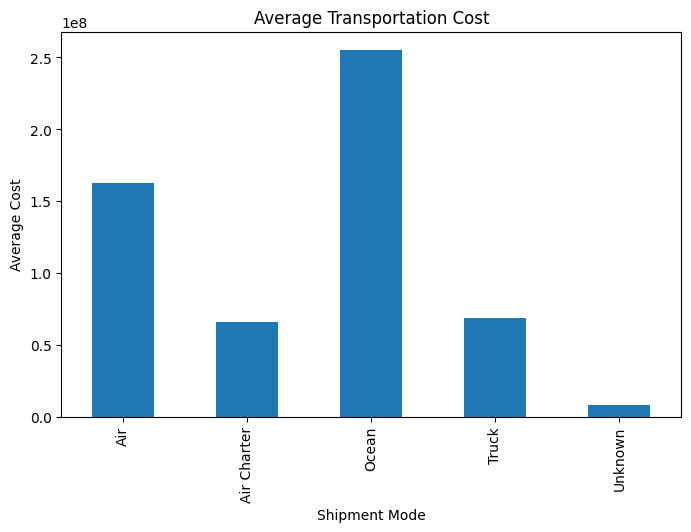

In [67]:
# =========================================================
# Transportation Cost Chart
# =========================================================

plt.figure(figsize=(8,5))

shipping_analysis.plot(kind='bar')

plt.title('Average Transportation Cost')
plt.xlabel('Shipment Mode')
plt.ylabel('Average Cost')

plt.show()

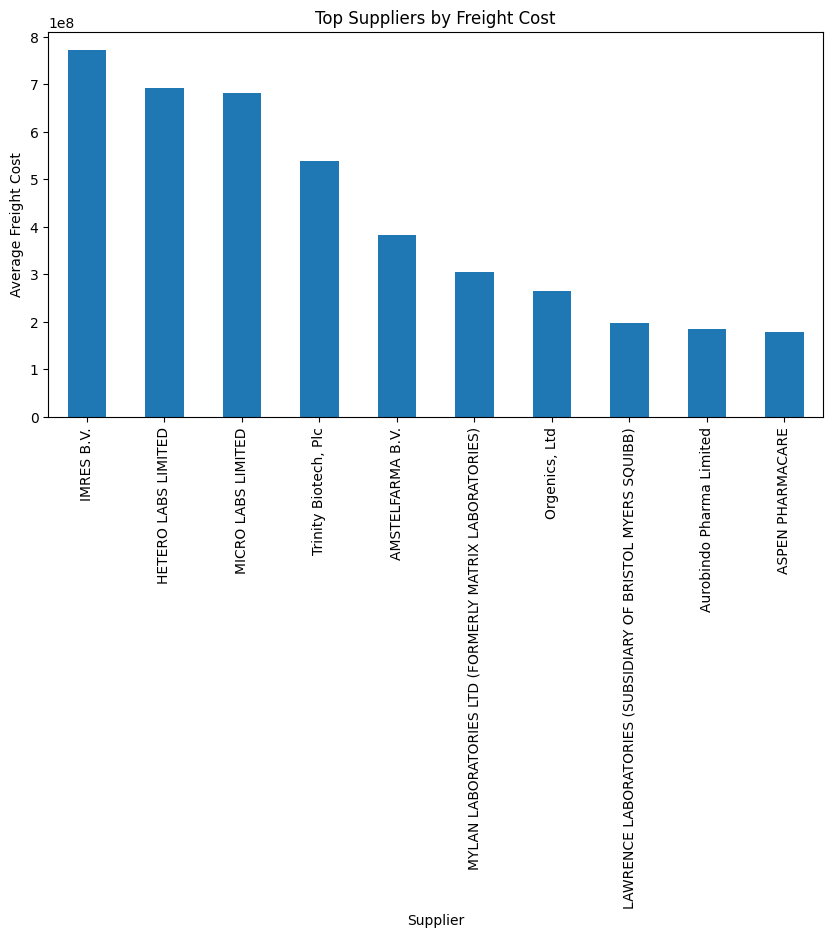

In [68]:
# =========================================================
# SUPPLIER ANALYSIS CHART
# =========================================================

top_suppliers = supplier_performance.head(10)

plt.figure(figsize=(10,5))

top_suppliers.plot(kind='bar')

plt.title('Top Suppliers by Freight Cost')
plt.xlabel('Supplier')
plt.ylabel('Average Freight Cost')

plt.show()

In [70]:
# =========================================================
# SAVE CLEANED DATASET
# =========================================================

df.to_csv(
    'cleaned_supply_chain_data.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [72]:
forecast_df = df[[
    'Line Item Quantity',
    'Total Cost'
]]

forecast_df.to_csv(
    'forecast_data.csv',
    index=False
)
delay_df = df[[
    'Shipment Mode',
    'Country',
    'Freight Cost (USD)',
    'Delayed'
]]

delay_df.to_csv(
    'delay_prediction_data.csv',
    index=False
)
supplier_df = df[[
    'Vendor',
    'Freight Cost (USD)',
    'Delivery Days'
]]

supplier_df.to_csv(
    'supplier_analytics.csv',
    index=False
)


In [69]:
# =========================================================
# FINAL BUSINESS INSIGHTS
# =========================================================

print("Business Insights:")

print("1. Some shipment modes are more expensive.")
print("2. Delayed deliveries affect logistics efficiency.")
print("3. Certain suppliers have higher transportation costs.")
print("4. KMeans identified inventory behavior groups.")
print("5. Demand forecasting helps future planning.")


# =========================================================
# END OF PROJECT
# =========================================================

Business Insights:
1. Some shipment modes are more expensive.
2. Delayed deliveries affect logistics efficiency.
3. Certain suppliers have higher transportation costs.
4. KMeans identified inventory behavior groups.
5. Demand forecasting helps future planning.
